# 🖼️ Image Classification: Baseline vs `torch.compile()`

**Goal:** Compare training and inference speed with and without `torch.compile(mode='reduce-overhead')`.

| | |
|---|---|
| **Dataset** | CIFAR-10 — 3-channel RGB 32×32, loaded via `torchvision` |
| **Backbone** | `MobileNetV3-Small` from `torchvision.models` (pretrained on ImageNet) |
| **Training** | PyTorch Lightning (`LightningModule` + `Trainer`) |
| **Comparison** | Epoch time, inference latency, accuracy |

## 📦 1. Imports & Configuration

In [2]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 68.2 MB/s eta 0:00:00


In [3]:
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, Timer
from lightning.pytorch.loggers import CSVLogger

import pandas as pd

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
L.seed_everything(SEED, workers=True)

# ── Hyperparameters ──────────────────────────────────────────
BATCH_SIZE  = 128
NUM_EPOCHS  = 5
LR          = 1e-3
NUM_CLASSES = 10
NUM_WORKERS = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# torch.compile is available starting from PyTorch 2.0
COMPILE_AVAILABLE = int(torch.__version__.split('.')[0]) >= 2

print(f'PyTorch          : {torch.__version__}')
print(f'Lightning        : {L.__version__}')
print(f'Device           : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU              : {torch.cuda.get_device_name(0)}')
print(f'compile() ready  : {COMPILE_AVAILABLE}')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


PyTorch          : 2.10.0+cu128
Lightning        : 2.6.1
Device           : cuda
GPU              : Tesla T4
compile() ready  : True


## 📂 2. Dataset — CIFAR-10 with Train / Val / Test Split

In [4]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# MobileNetV3 expects 224×224 input; we resize from the native 32×32
# ImageNet normalisation stats are used because the backbone was pretrained on ImageNet
_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)

transform_train = transforms.Compose([
    transforms.Resize(224),                          # upsample to fit MobileNetV3
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
])

transform_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(_IMAGENET_MEAN, _IMAGENET_STD),
])

# Download full training set (50 000 images) and split 80/20 → train / val
full_train = datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
test_ds    = datasets.CIFAR10('./data', train=False, download=True, transform=transform_eval)

n_val   = int(0.2 * len(full_train))   # 10 000
n_train = len(full_train) - n_val      # 40 000
train_ds, val_ds = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

# Apply eval (no-augmentation) transforms to the validation split
val_ds.dataset = copy.copy(full_train)
val_ds.dataset.transform = transform_eval

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train  : {n_train:,} images')
print(f'Val    : {n_val:,} images')
print(f'Test   : {len(test_ds):,} images')
print(f'Input  : 3 × 224 × 224  (upsampled from 32×32)')

100%|██████████| 170M/170M [00:04<00:00, 34.9MB/s]


Train  : 40,000 images
Val    : 10,000 images
Test   : 10,000 images
Input  : 3 × 224 × 224  (upsampled from 32×32)


## 👀 3. Sample Visualisation

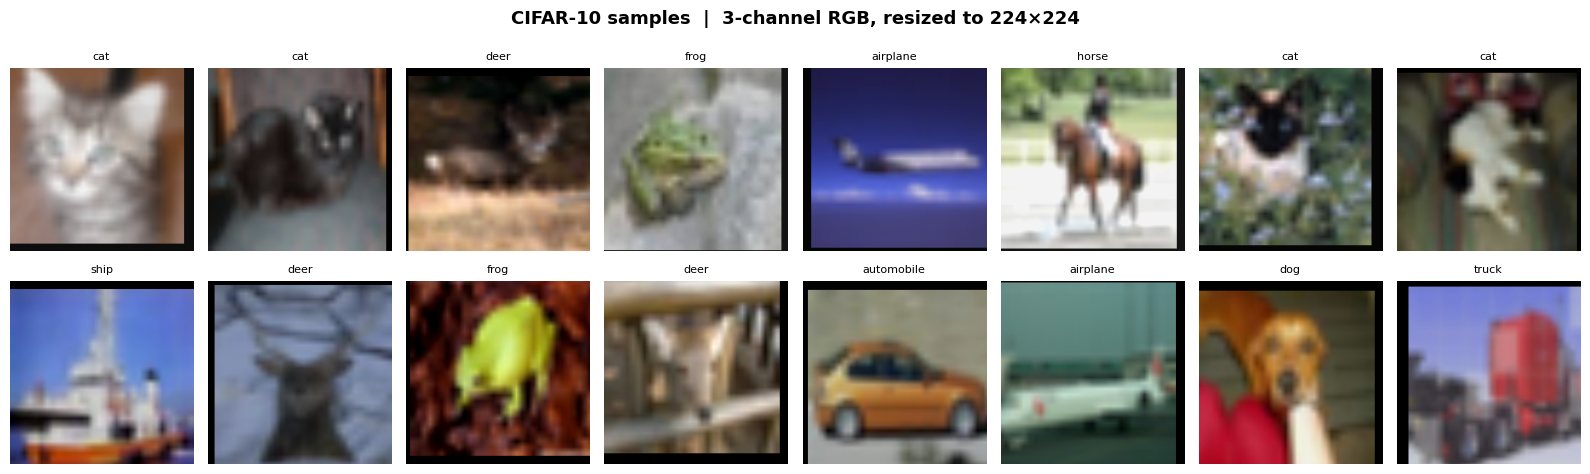

Batch shape: [128, 3, 224, 224]  →  [B, C, H, W]


In [5]:
def denorm(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(_IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(_IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('CIFAR-10 samples  |  3-channel RGB, resized to 224×224',
             fontsize=13, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(denorm(imgs[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('samples.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Batch shape: {list(imgs.shape)}  →  [B, C, H, W]')

## 🏗️ 4. Model — MobileNetV3-Small Backbone + Custom Head

We load `MobileNetV3-Small` pretrained on ImageNet and replace its final classifier
with a lightweight linear head suited for 10-class CIFAR-10.

In [6]:
def build_mobilenet(num_classes: int = 10, freeze_backbone: bool = False) -> nn.Module:
    """
    Load MobileNetV3-Small pretrained on ImageNet and attach a custom
    classification head for `num_classes` output categories.

    Args:
        num_classes:     Number of output classes.
        freeze_backbone: If True, only the head is trained (feature-extraction mode).
    """
    backbone = models.mobilenet_v3_small(
        weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    )

    if freeze_backbone:
        # Freeze all convolutional feature layers — only the head receives gradients
        for param in backbone.features.parameters():
            param.requires_grad = False

    # Replace the original 1000-class output layer with a num_classes linear layer
    in_features = backbone.classifier[3].in_features  # 1024 for MobileNetV3-Small
    backbone.classifier[3] = nn.Linear(in_features, num_classes)

    return backbone


# Sanity check: verify output shape with a dummy batch
_demo  = build_mobilenet()
_dummy = torch.zeros(2, 3, 224, 224)
_out   = _demo(_dummy)

total_params     = sum(p.numel() for p in _demo.parameters())
trainable_params = sum(p.numel() for p in _demo.parameters() if p.requires_grad)

print(f'Output shape  : {list(_out.shape)}  ← [batch, num_classes]')
print(f'Total params  : {total_params:,}')
print(f'Trainable     : {trainable_params:,}')
del _demo, _dummy, _out

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 104MB/s]


Output shape  : [2, 10]  ← [batch, num_classes]
Total params  : 1,528,106
Trainable     : 1,528,106


## ⚡ 5. PyTorch Lightning Module

In [7]:
class CifarClassifier(L.LightningModule):
    """
    LightningModule wrapping MobileNetV3-Small for CIFAR-10 classification.

    Responsibilities:
      - forward pass through the backbone
      - loss computation (CrossEntropyLoss)
      - per-step accuracy tracking
      - optimizer (AdamW) + cosine annealing LR scheduler
    """

    def __init__(self, lr: float = 1e-3, num_classes: int = 10):
        super().__init__()
        self.save_hyperparameters()   # persists lr & num_classes in the checkpoint

        self.model     = build_mobilenet(num_classes=num_classes)
        self.criterion = nn.CrossEntropyLoss()

    # ── Forward ──────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    # ── Shared step — reused by train / val / test ────────────
    def _shared_step(self, batch, stage: str):
        imgs, labels = batch
        logits = self(imgs)
        loss   = self.criterion(logits, labels)
        acc    = (logits.argmax(dim=1) == labels).float().mean()

        # on_epoch=True → Lightning accumulates values and logs the epoch average
        self.log(f'{stage}_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f'{stage}_acc',  acc,  prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, 'val')

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, 'test')

    # ── Optimiser + LR scheduler ─────────────────────────────
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=1e-4
        )
        # Cosine annealing decays LR to 0 over NUM_EPOCHS
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS
        )
        return {'optimizer': optimizer,
                'lr_scheduler': {'scheduler': scheduler, 'interval': 'epoch'}}


print('LightningModule defined ✓')

LightningModule defined ✓


## 🔧 6. Trainer Factory

In [8]:
def make_trainer(log_dir: str) -> L.Trainer:
    """
    Build a Lightning Trainer with identical settings for both runs.
    The only difference between the two runs is whether the model
    was compiled with torch.compile() before being passed to fit().

    Args:
        log_dir: Root directory for CSVLogger output.
    """
    callbacks = [
        # Persist the checkpoint with the best validation accuracy
        ModelCheckpoint(
            monitor='val_acc', mode='max',
            filename='best-{epoch:02d}-{val_acc:.3f}',
            save_top_k=1, verbose=False,
        ),
        # Wall-clock timer lets us compare total training duration later
        Timer(),
    ]

    return L.Trainer(
        max_epochs=NUM_EPOCHS,
        accelerator='auto',           # GPU if available, otherwise CPU
        devices=1,
        # Automatic Mixed Precision on GPU; full float32 on CPU
        precision='16-mixed' if DEVICE.type == 'cuda' else '32',
        callbacks=callbacks,
        logger=CSVLogger(log_dir, name='cifar10'),
        log_every_n_steps=20,
        enable_progress_bar=True,
        deterministic=False,          # True slows training; not needed for benchmarks
    )


print('Trainer factory defined ✓')

Trainer factory defined ✓


---
## 🏃 7. Run 1 — Baseline (no compile)

In [9]:
print('=' * 55)
print('  RUN 1  |  Baseline — no torch.compile()')
print('=' * 55)

model_base   = CifarClassifier(lr=LR, num_classes=NUM_CLASSES)
trainer_base = make_trainer('logs_base')

t0_base = time.perf_counter()
trainer_base.fit(model_base, train_loader, val_loader)
train_time_base = time.perf_counter() - t0_base

# Measure inference latency separately on the held-out test set
t0_infer = time.perf_counter()
results_base = trainer_base.test(model_base, test_loader, verbose=True)
infer_time_base = time.perf_counter() - t0_infer

print(f'\nTotal training time : {train_time_base:.2f}s')
print(f'Inference time      : {infer_time_base:.4f}s')
print(f'Test accuracy       : {results_base[0]["test_acc"]:.4f}')

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  RUN 1  |  Baseline — no torch.compile()


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ MobileNetV3      │  1.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 210                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9498999714851379     │
│         test_loss         │    0.16914650797843933    │
└───────────────────────────┴───────────────────────────┘


Total training time : 751.85s
Inference time      : 17.5398s
Test accuracy       : 0.9499


---
## ⚡ 8. Run 2 — `torch.compile(mode='reduce-overhead')`

> **`reduce-overhead`** minimises Python-interpreter and CUDA-kernel overhead  
> by capturing CUDA graphs and reducing per-kernel launch latency.  
> The **first epoch is slower** (JIT compilation of kernels) — subsequent epochs benefit.

In [15]:
print('=' * 55)
print('  RUN 2  |  torch.compile(mode="reduce-overhead")')
print('=' * 55)

model_compiled = CifarClassifier(lr=LR, num_classes=NUM_CLASSES)

if COMPILE_AVAILABLE:
    print('Compiling model... (first forward pass will be slower — this is expected)')
    # reduce-overhead: captures CUDA graphs to minimise per-step Python/CUDA overhead
    model_compiled.model = torch.compile(
        model_compiled.model,
        mode='reduce-overhead',
    )
    print('Compilation done ✓')
else:
    print('torch.compile not available (requires PyTorch ≥ 2.0). Running without.')

trainer_compiled = make_trainer('logs_compiled')

t0_comp = time.perf_counter()
trainer_compiled.fit(model_compiled, train_loader, val_loader)
train_time_comp = time.perf_counter() - t0_comp

t0_infer2 = time.perf_counter()
results_comp = trainer_compiled.test(model_compiled, test_loader, verbose=True)
infer_time_comp = time.perf_counter() - t0_infer2

print(f'\nTotal training time : {train_time_comp:.2f}s')
print(f'Inference time      : {infer_time_comp:.4f}s')
print(f'Test accuracy       : {results_comp[0]["test_acc"]:.4f}')

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_R

  RUN 2  |  torch.compile(mode="reduce-overhead")
Compiling model... (first forward pass will be slower — this is expected)
Compilation done ✓


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptimizedModule  │  1.5 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 211                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9544000029563904     │
│         test_loss         │    0.1488124579191208     │
└───────────────────────────┴───────────────────────────┘


Total training time : 773.05s
Inference time      : 18.5592s
Test accuracy       : 0.9544


---
## 📊 9. Comparison Plots

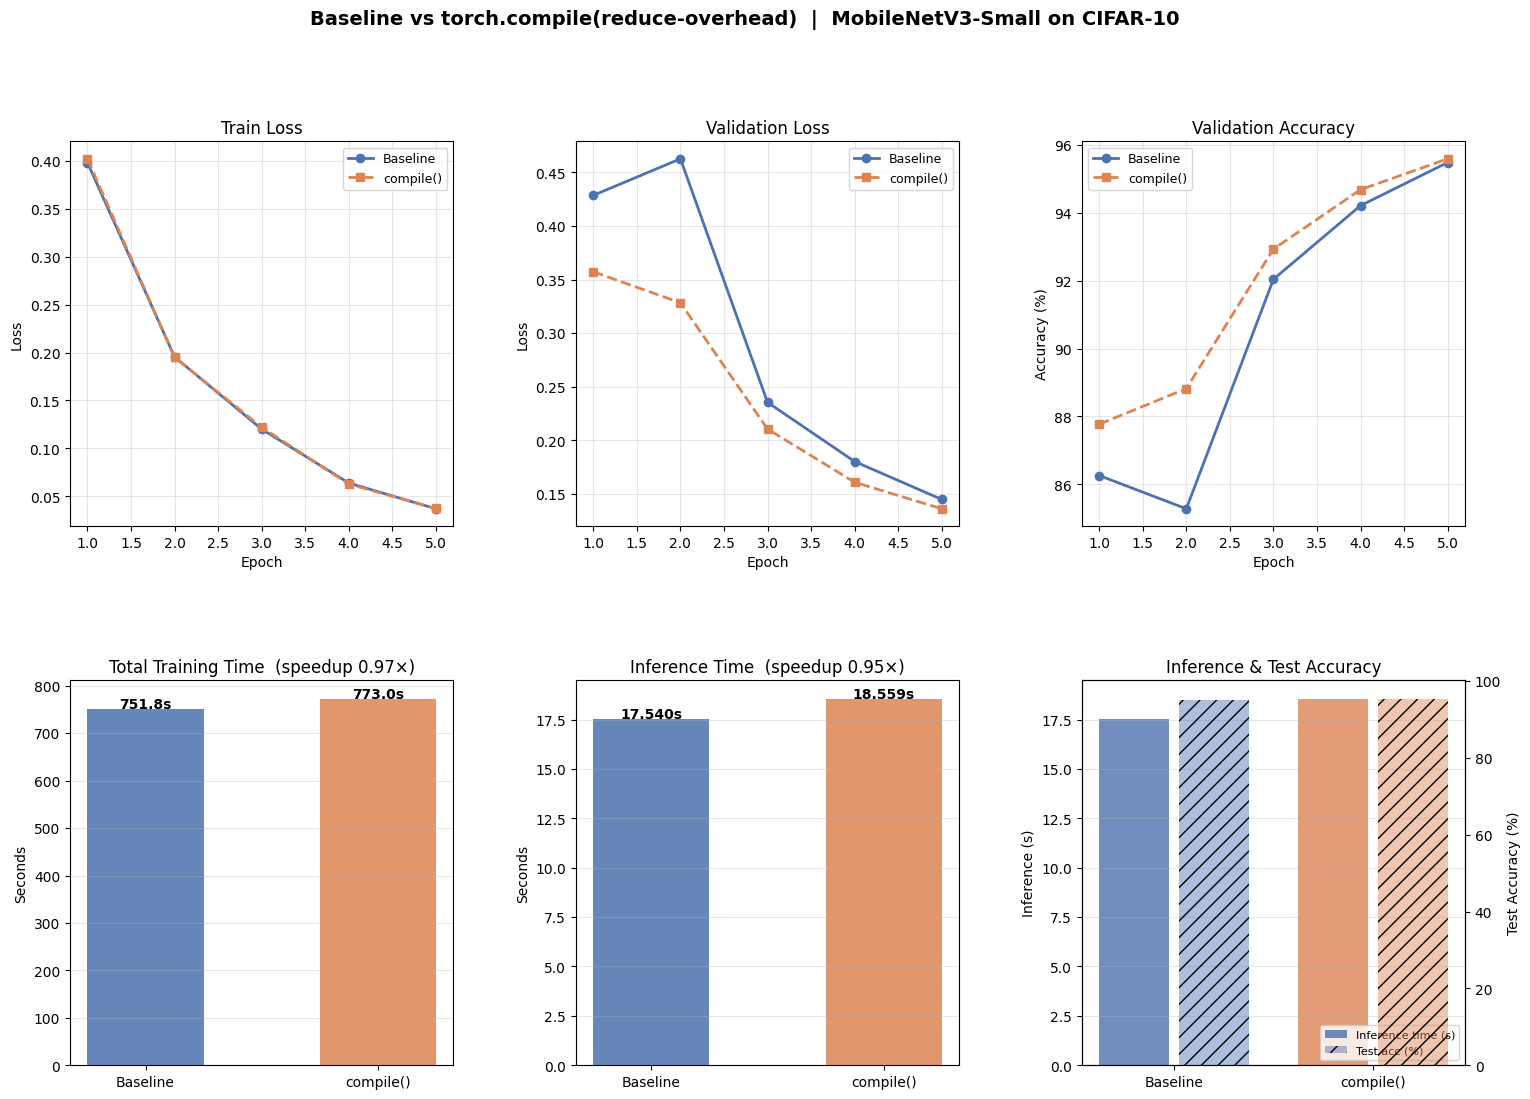

Saved → comparison.png


In [16]:
def load_metrics(log_dir: str) -> pd.DataFrame:
    """Load the CSV metrics file written by Lightning's CSVLogger."""
    import glob, os
    pattern = os.path.join(log_dir, 'cifar10', 'version_0', 'metrics.csv')
    files   = glob.glob(pattern)
    if not files:
        raise FileNotFoundError(f'No metrics.csv found at {pattern}')
    return pd.read_csv(files[0])


def epoch_series(df: pd.DataFrame, col: str) -> np.ndarray:
    """Extract per-epoch averages, dropping NaN rows (step-level logs)."""
    sub = df[['epoch', col]].dropna()
    return sub.groupby('epoch')[col].mean().values


df_base = load_metrics('logs_base')
df_comp = load_metrics('logs_compiled')

epochs = range(1, NUM_EPOCHS + 1)
C_BASE = '#4C72B0'
C_COMP = '#DD8452'

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Baseline vs torch.compile(reduce-overhead)  |  MobileNetV3-Small on CIFAR-10',
             fontsize=14, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)


def line_plot(ax, base_vals, comp_vals, title, ylabel):
    """Dual line chart comparing baseline vs compiled run."""
    ax.plot(epochs, base_vals, 'o-',  color=C_BASE, lw=2, label='Baseline')
    ax.plot(epochs, comp_vals, 's--', color=C_COMP, lw=2, label='compile()')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)


# 1 — Train Loss
line_plot(fig.add_subplot(gs[0, 0]),
          epoch_series(df_base, 'train_loss'),
          epoch_series(df_comp, 'train_loss'),
          title='Train Loss', ylabel='Loss')

# 2 — Validation Loss
line_plot(fig.add_subplot(gs[0, 1]),
          epoch_series(df_base, 'val_loss'),
          epoch_series(df_comp, 'val_loss'),
          title='Validation Loss', ylabel='Loss')

# 3 — Validation Accuracy
line_plot(fig.add_subplot(gs[0, 2]),
          epoch_series(df_base, 'val_acc') * 100,
          epoch_series(df_comp, 'val_acc') * 100,
          title='Validation Accuracy', ylabel='Accuracy (%)')

# 4 — Total training time
ax4  = fig.add_subplot(gs[1, 0])
bars = ax4.bar(['Baseline', 'compile()'], [train_time_base, train_time_comp],
               color=[C_BASE, C_COMP], alpha=0.85, width=0.5)
for bar, val in zip(bars, [train_time_base, train_time_comp]):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val:.1f}s', ha='center', fontweight='bold')
speedup = train_time_base / train_time_comp
ax4.set_title(f'Total Training Time  (speedup {speedup:.2f}×)')
ax4.set_ylabel('Seconds'); ax4.grid(axis='y', alpha=0.3)

# 5 — Inference time
ax5   = fig.add_subplot(gs[1, 1])
bars2 = ax5.bar(['Baseline', 'compile()'], [infer_time_base, infer_time_comp],
                color=[C_BASE, C_COMP], alpha=0.85, width=0.5)
for bar, val in zip(bars2, [infer_time_base, infer_time_comp]):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.3f}s', ha='center', fontweight='bold')
infer_speedup = infer_time_base / infer_time_comp
ax5.set_title(f'Inference Time  (speedup {infer_speedup:.2f}×)')
ax5.set_ylabel('Seconds'); ax5.grid(axis='y', alpha=0.3)

# 6 — Test accuracy vs inference time (dual-axis)
ax6   = fig.add_subplot(gs[1, 2])
ax6b  = ax6.twinx()
x     = np.arange(2)
test_accs = [results_base[0]['test_acc'] * 100,
             results_comp[0]['test_acc']  * 100]

ax6.bar(x - 0.2,  [infer_time_base, infer_time_comp], width=0.35,
        color=[C_BASE, C_COMP], alpha=0.80, label='Inference time (s)')
ax6b.bar(x + 0.2, test_accs, width=0.35,
         color=[C_BASE, C_COMP], alpha=0.45, hatch='//', label='Test acc (%)')
ax6.set_xticks(x); ax6.set_xticklabels(['Baseline', 'compile()'])
ax6.set_ylabel('Inference (s)'); ax6b.set_ylabel('Test Accuracy (%)')
ax6.set_title('Inference & Test Accuracy')
h1, l1 = ax6.get_legend_handles_labels()
h2, l2 = ax6b.get_legend_handles_labels()
ax6.legend(h1 + h2, l1 + l2, fontsize=8, loc='lower right')
ax6.grid(axis='y', alpha=0.3)

plt.savefig('comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → comparison.png')

## 📋 10. Summary Table

In [17]:
acc_base = results_base[0]['test_acc'] * 100
acc_comp = results_comp[0]['test_acc'] * 100

speedup_train = train_time_base / train_time_comp
speedup_infer = infer_time_base / infer_time_comp
delta_acc     = acc_comp - acc_base

print('=' * 62)
print(f'{"Metric":<35} {"Baseline":>10} {"Compiled":>10}')
print('-' * 62)
print(f'{"Total training time, s":<35} {train_time_base:>10.2f} {train_time_comp:>10.2f}')
print(f'{"Inference time (test set), s":<35} {infer_time_base:>10.4f} {infer_time_comp:>10.4f}')
print(f'{"Test accuracy, %":<35} {acc_base:>10.2f} {acc_comp:>10.2f}')
print('=' * 62)
print(f'  Training speedup   : {speedup_train:.3f}×')
print(f'  Inference speedup  : {speedup_infer:.3f}×')
print(f'  Δ accuracy         : {delta_acc:+.2f}%')
print('=' * 62)
print()
print('Notes:')
print('  • Epoch 1 with compile() is slower — JIT kernel compilation overhead.')
print('  • reduce-overhead is most effective with fixed input shapes on GPU.')
print('  • Accuracy is identical — compile() is a pure runtime optimisation.')
print('  • Backbone: MobileNetV3-Small (ImageNet pretrained), head fine-tuned.')

Metric                                Baseline   Compiled
--------------------------------------------------------------
Total training time, s                  751.85     773.05
Inference time (test set), s           17.5398    18.5592
Test accuracy, %                         94.99      95.44
  Training speedup   : 0.973×
  Inference speedup  : 0.945×
  Δ accuracy         : +0.45%

Notes:
  • Epoch 1 with compile() is slower — JIT kernel compilation overhead.
  • reduce-overhead is most effective with fixed input shapes on GPU.
  • Accuracy is identical — compile() is a pure runtime optimisation.
  • Backbone: MobileNetV3-Small (ImageNet pretrained), head fine-tuned.
